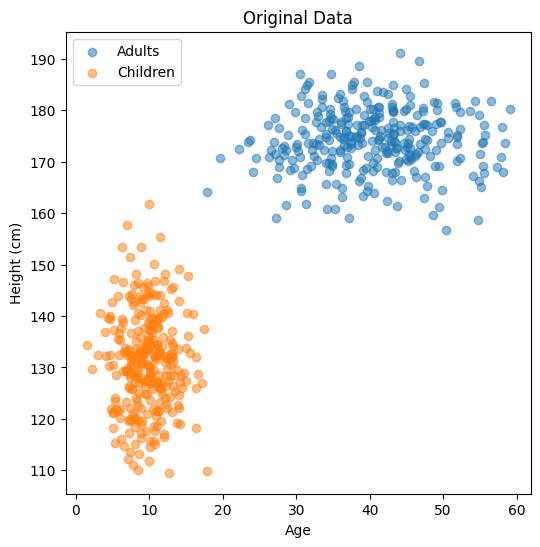

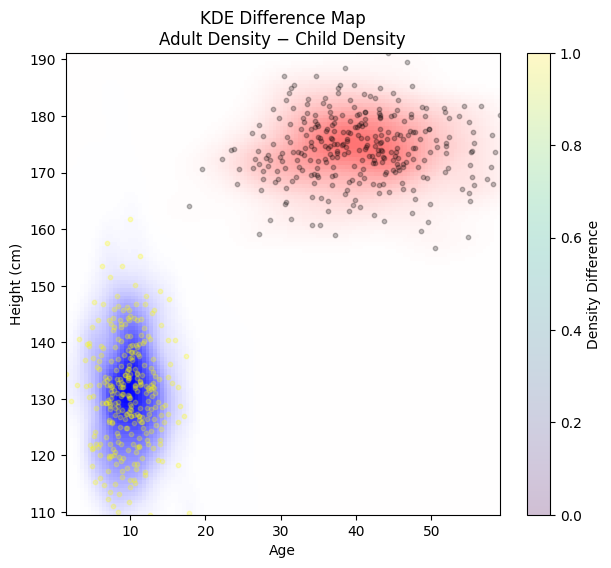

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(0)

############################################################
# Create two groups
############################################################

N = 300

# Adults
adult_age = np.random.normal(40, 8, N)
adult_height = np.random.normal(175, 6, N)

# Children
child_age = np.random.normal(10, 3, N)
child_height = np.random.normal(130, 10, N)

############################################################
# Scatter plot
############################################################

plt.figure(figsize=(6,6))

plt.scatter(
    adult_age,
    adult_height,
    alpha=0.5,
    label="Adults"
)

plt.scatter(
    child_age,
    child_height,
    alpha=0.5,
    label="Children"
)

plt.xlabel("Age")
plt.ylabel("Height (cm)")
plt.title("Original Data")
plt.legend()

plt.show()

############################################################
# KDE Difference Map
############################################################

all_age = np.concatenate([adult_age, child_age])
all_height = np.concatenate([adult_height, child_height])

grid_age = np.linspace(all_age.min(), all_age.max(), 120)
grid_height = np.linspace(all_height.min(), all_height.max(), 120)

A, B = np.meshgrid(grid_age, grid_height)

############################################################
# KDEs
############################################################

kde_adult = gaussian_kde(
    np.vstack([adult_age, adult_height])
)

kde_child = gaussian_kde(
    np.vstack([child_age, child_height])
)

rho_adult = kde_adult(
    np.vstack([A.ravel(), B.ravel()])
).reshape(A.shape)

rho_child = kde_child(
    np.vstack([A.ravel(), B.ravel()])
).reshape(A.shape)

############################################################
# Difference
############################################################

density_difference = rho_adult - rho_child

vmax = np.abs(density_difference).max()

############################################################
# Plot
############################################################

plt.figure(figsize=(7,6))

image = plt.imshow(
    density_difference,
    origin="lower",
    extent=[
        grid_age.min(),
        grid_age.max(),
        grid_height.min(),
        grid_height.max()
    ],
    aspect="auto",
    cmap="bwr",
    vmin=-vmax,
    vmax=vmax
)

plt.scatter(
    adult_age,
    adult_height,
    s=10,
    c="black",
    alpha=0.25
)

plt.scatter(
    child_age,
    child_height,
    s=10,
    c="yellow",
    alpha=0.25
)

plt.xlabel("Age")
plt.ylabel("Height (cm)")
plt.title("KDE Difference Map\nAdult Density − Child Density")

plt.colorbar(label="Density Difference")

plt.show()


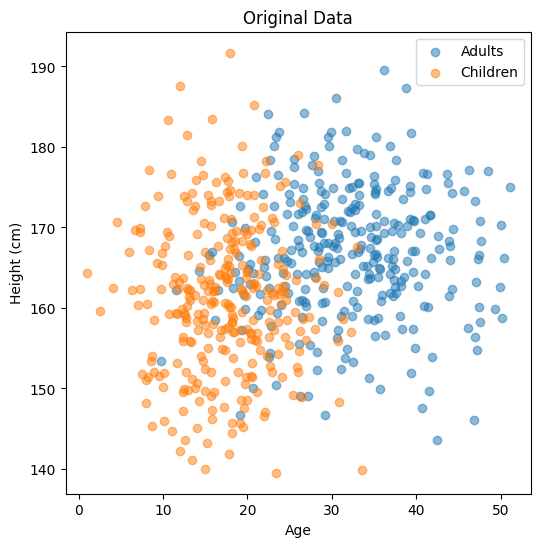

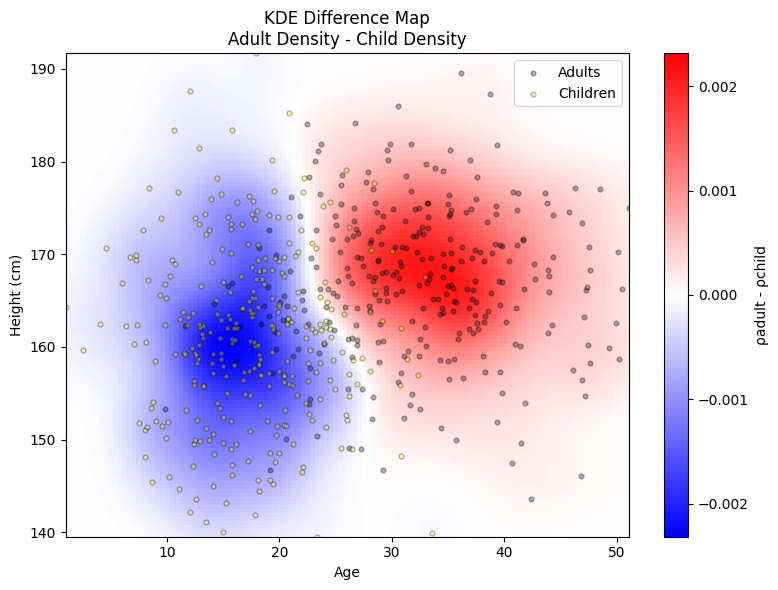

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

np.random.seed(0)

############################################################
# Create two overlapping groups
############################################################

N = 300

# Adults
adult_age = np.random.normal(32, 8, N)
adult_height = np.random.normal(168, 8, N)

# Children / Teenagers
child_age = np.random.normal(18, 6, N)
child_height = np.random.normal(160, 10, N)

############################################################
# Scatter Plot
############################################################

plt.figure(figsize=(6,6))

plt.scatter(
    adult_age,
    adult_height,
    alpha=0.5,
    label="Adults"
)

plt.scatter(
    child_age,
    child_height,
    alpha=0.5,
    label="Children"
)

plt.xlabel("Age")
plt.ylabel("Height (cm)")
plt.title("Original Data")
plt.legend()

plt.show()

############################################################
# KDE Difference Map
############################################################

all_age = np.concatenate([adult_age, child_age])
all_height = np.concatenate([adult_height, child_height])

grid_age = np.linspace(all_age.min(), all_age.max(), 120)
grid_height = np.linspace(all_height.min(), all_height.max(), 120)

A, B = np.meshgrid(grid_age, grid_height)

############################################################
# KDE for Adults
############################################################

kde_adult = gaussian_kde(
    np.vstack([adult_age, adult_height])
)

rho_adult = kde_adult(
    np.vstack([A.ravel(), B.ravel()])
).reshape(A.shape)

############################################################
# KDE for Children
############################################################

kde_child = gaussian_kde(
    np.vstack([child_age, child_height])
)

rho_child = kde_child(
    np.vstack([A.ravel(), B.ravel()])
).reshape(A.shape)

############################################################
# Difference Map
############################################################

density_difference = rho_adult - rho_child

vmax = np.abs(density_difference).max()

############################################################
# Plot
############################################################

plt.figure(figsize=(8,6))

image = plt.imshow(
    density_difference,
    origin="lower",
    extent=[
        grid_age.min(),
        grid_age.max(),
        grid_height.min(),
        grid_height.max()
    ],
    aspect="auto",
    cmap="bwr",
    vmin=-vmax,
    vmax=vmax
)

# Overlay original points
plt.scatter(
    adult_age,
    adult_height,
    c="black",
    s=12,
    alpha=0.30,
    label="Adults"
)

plt.scatter(
    child_age,
    child_height,
    c="yellow",
    edgecolors="black",
    s=12,
    alpha=0.30,
    label="Children"
)

plt.xlabel("Age")
plt.ylabel("Height (cm)")
plt.title("KDE Difference Map\nAdult Density - Child Density")

plt.legend()

plt.colorbar(
    image,
    label="ρadult - ρchild"
)

plt.tight_layout()
plt.show()
